Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [ ]:
from setup import *

# LH 1

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.68,3
,3000,0,0.54,7
,3000,0,0.59,3
,3000,0,0.65,7


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1947.64    61.72
p_loo       22.46        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



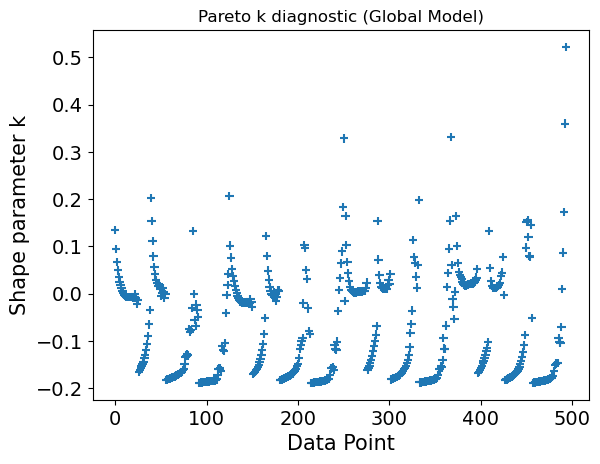

In [4]:
with pm.Model() as LH_1:
    '''
    1. CO + * -> CO* (RDS)
    2. CO* + OH* -> COOH* + * (Fast)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2) 

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact1 = Gact1_0 
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_OH]), axis=0)
    log_theta_OH = term_OH + log_theta

    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k1 + np.log(P_CO_in) + log_theta
    log_rate = observables(log_rate_model) 

trace_LH_1, loo_LH_1 = fit_and_evaluate(LH_1)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.071  0.005   0.064    0.080        0.0      0.0    1074.0    1413.0    1.0
Gact1_0    0.709  0.001   0.707    0.712        0.0      0.0    1424.0    1887.0    1.0


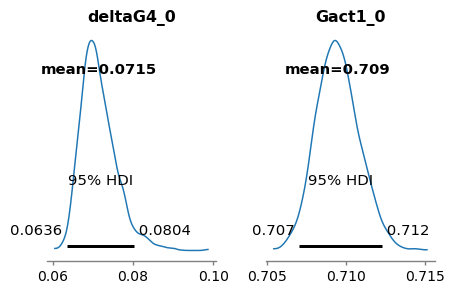

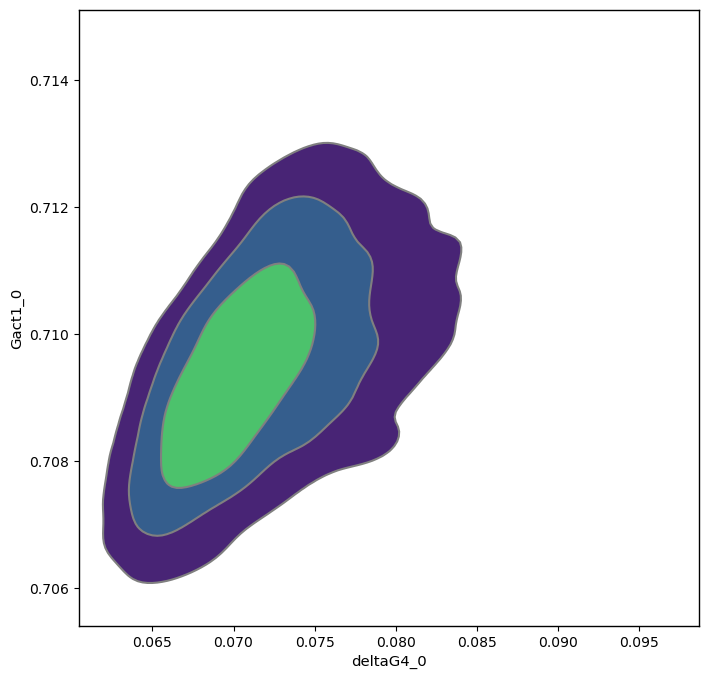

Sampling: [rate]


rate: 0.650


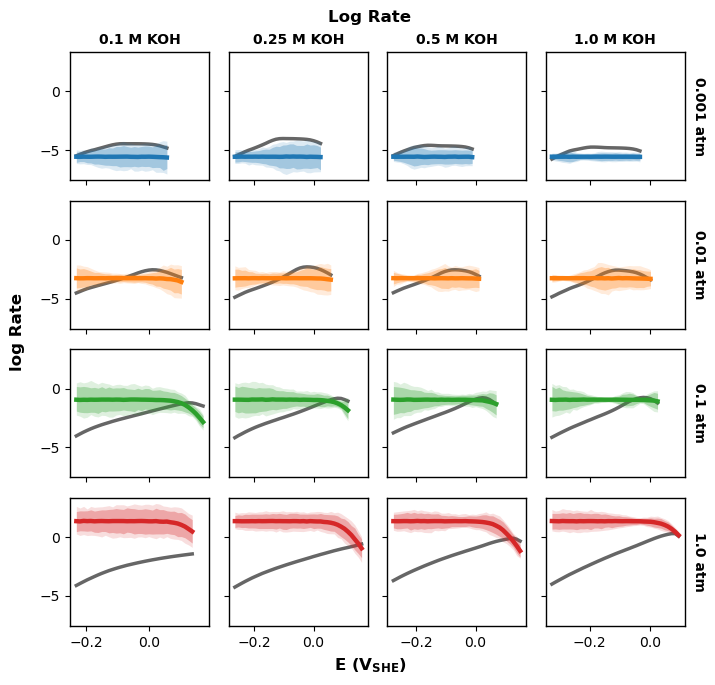

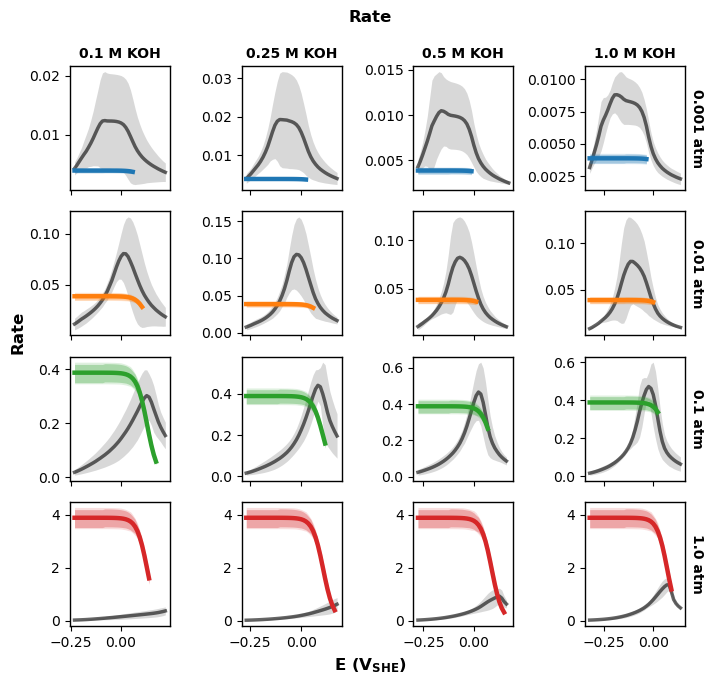

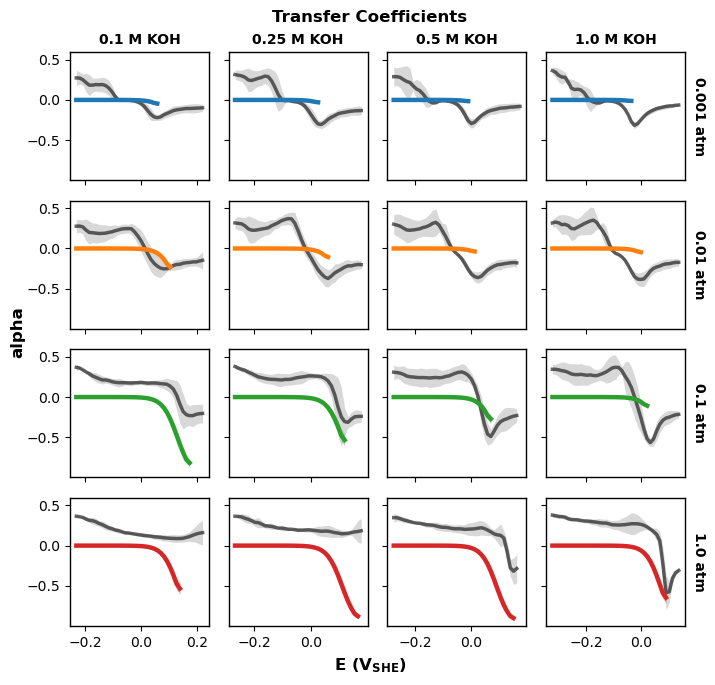

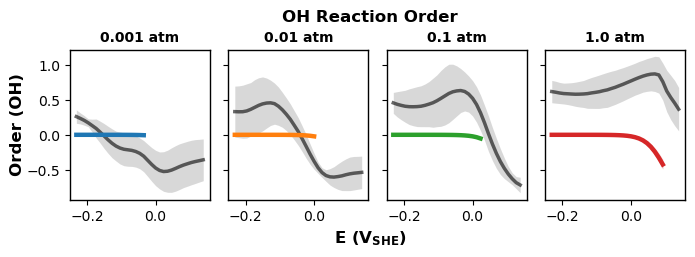

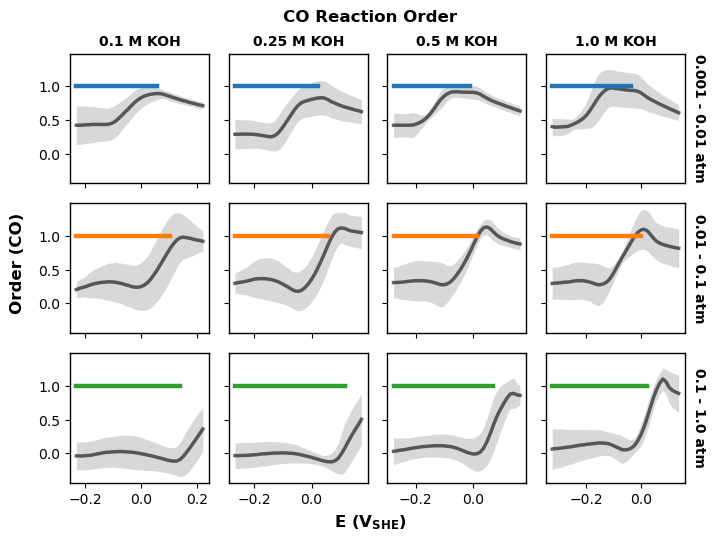

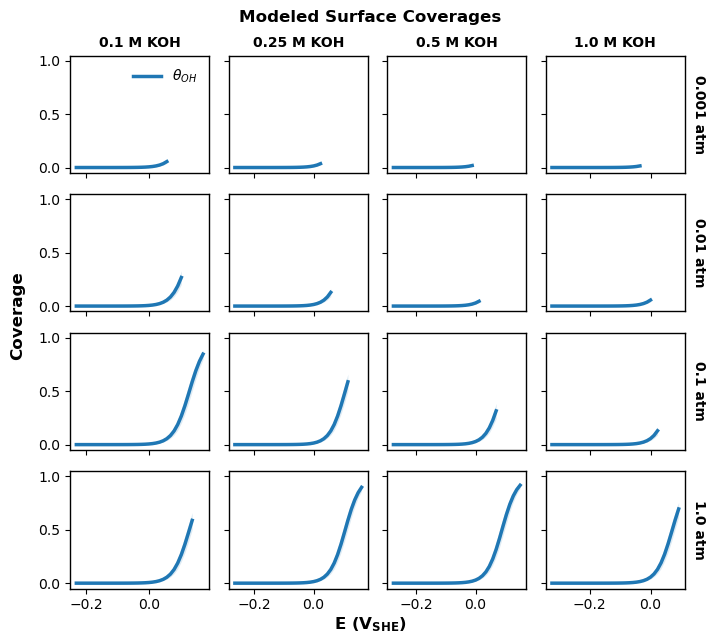

In [5]:
ppc_LH_1 = plot_posteriors(trace_LH_1, LH_1, plot_target)
plot_model_fits(trace_LH_1, ppc_LH_1); plot_coverages(trace_LH_1)

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.56,7
,3000,0,0.55,7
,3000,0,0.51,7
,3000,0,0.53,7


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2101.11    59.53
p_loo       75.41        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



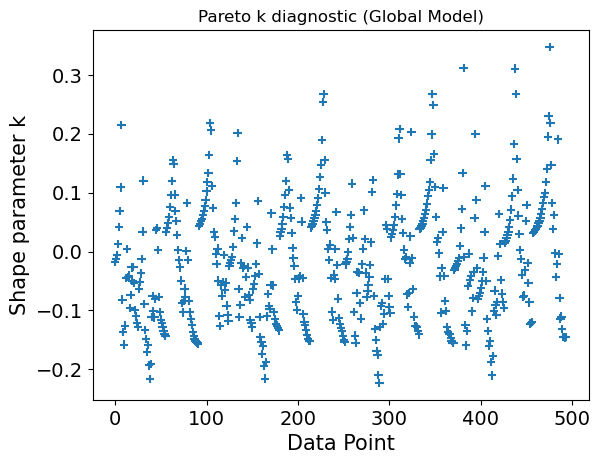

In [6]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + log_theta_OH 
    log_rate = observables(log_rate_model) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.091  0.004  -0.098   -0.084        0.0      0.0    1114.0    1513.0    1.0
deltaG4_0 -0.134  0.003  -0.139   -0.129        0.0      0.0    1569.0    1981.0    1.0
Gact2_0    0.705  0.003   0.700    0.710        0.0      0.0    1204.0    1835.0    1.0


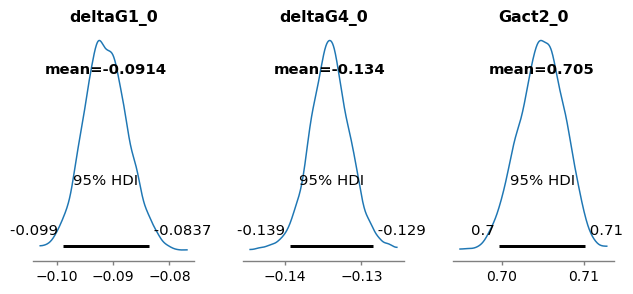

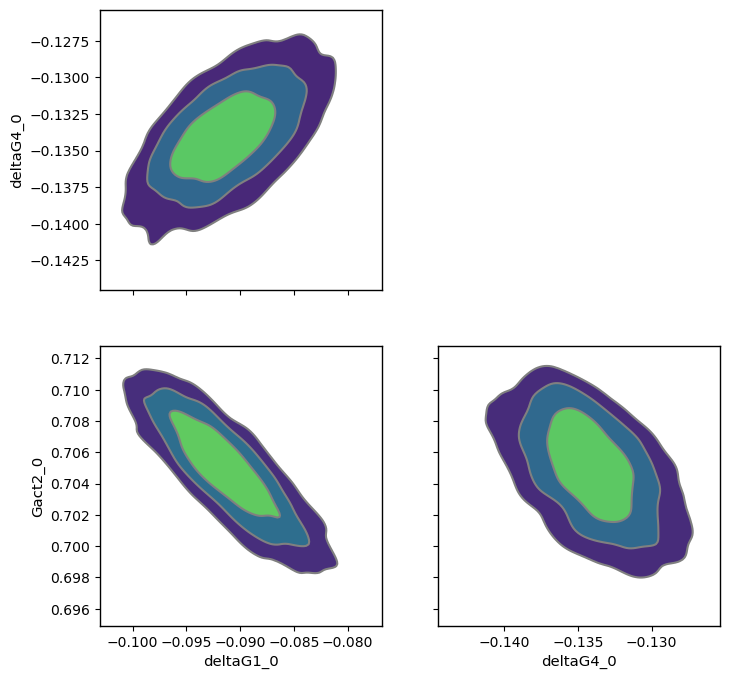

Sampling: [rate]


rate: 0.609


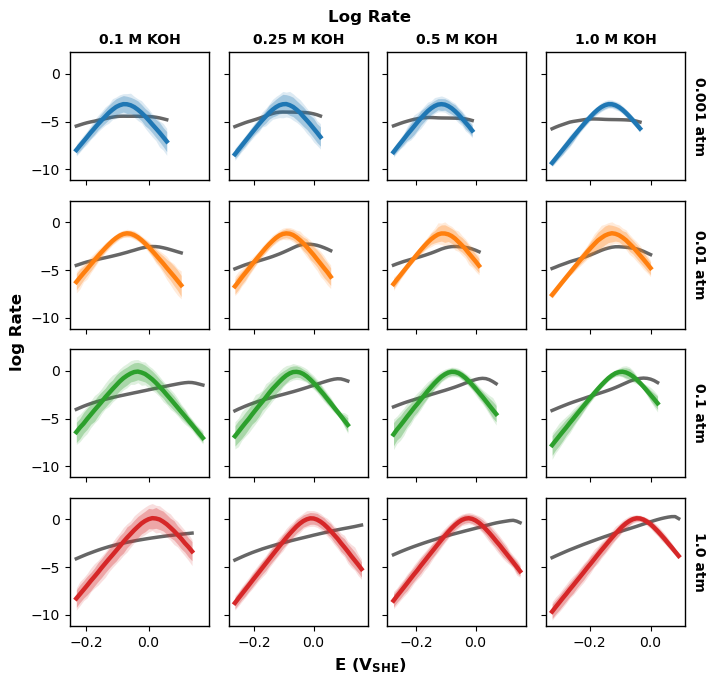

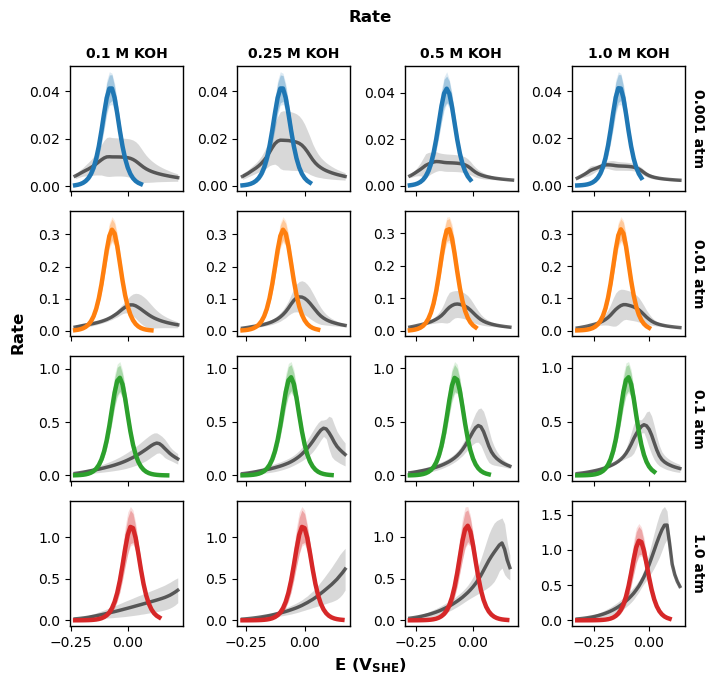

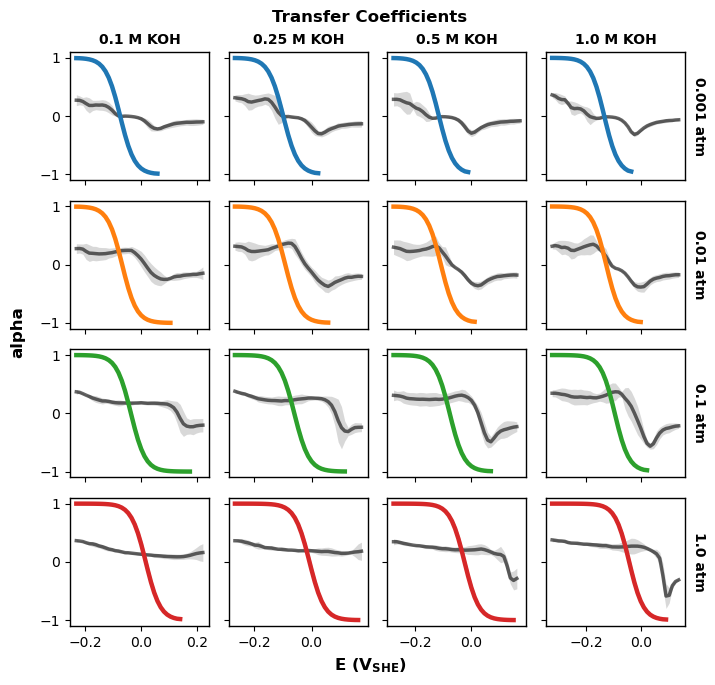

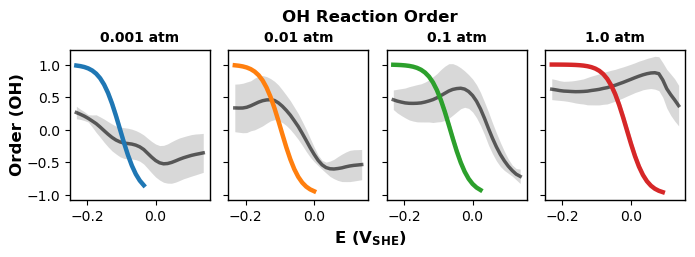

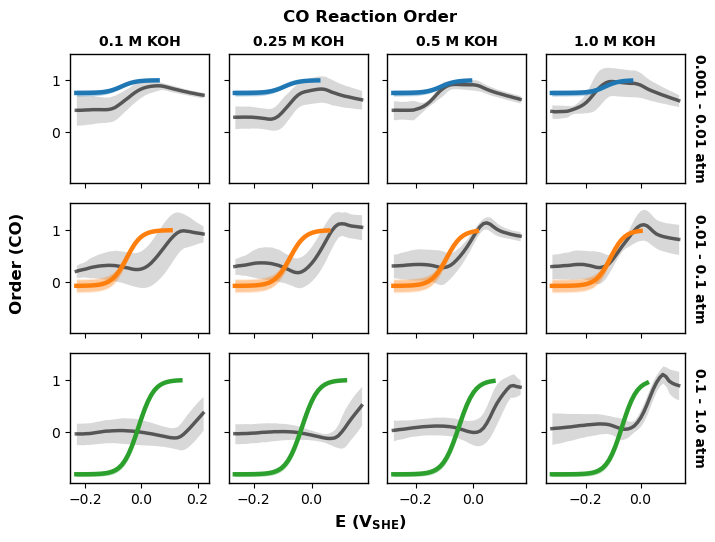

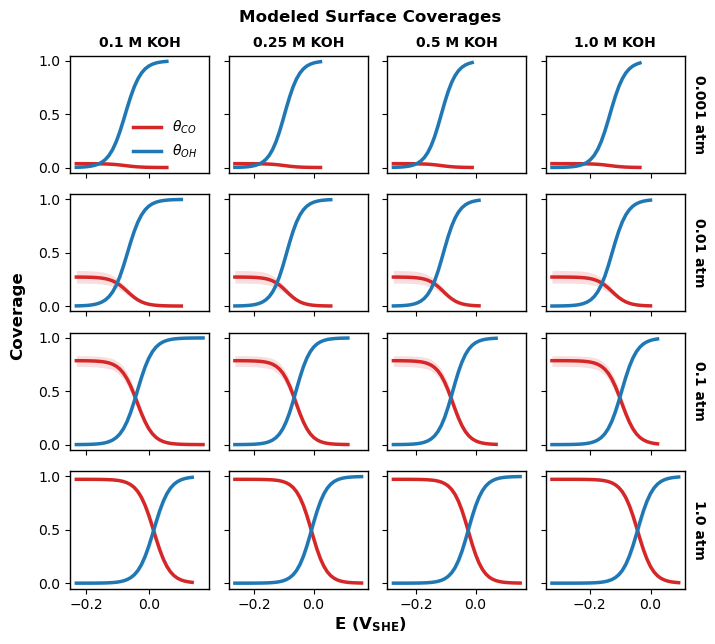

In [7]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2, plot_target)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.40,7
,3000,0,0.42,7
,3000,0,0.47,15
,3000,0,0.42,11


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -567.92    39.06
p_loo       20.78        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



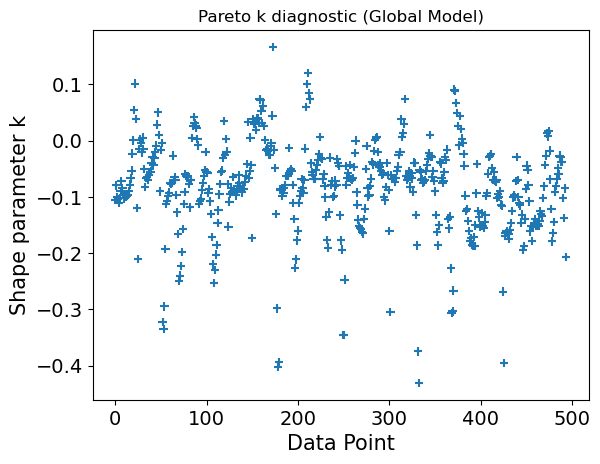

In [8]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + np.log(C_KOH_in)
    log_rate = observables(log_rate_model) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.124  0.002  -0.128   -0.120        0.0      0.0    1234.0    1624.0   1.00
deltaG4_0  0.001  0.013  -0.020    0.028        0.0      0.0    1155.0    1009.0   1.01
Gact2_0    0.748  0.001   0.747    0.749        0.0      0.0    1324.0    1914.0   1.01
beta_2     0.272  0.006   0.258    0.283        0.0      0.0    1086.0    1271.0   1.01


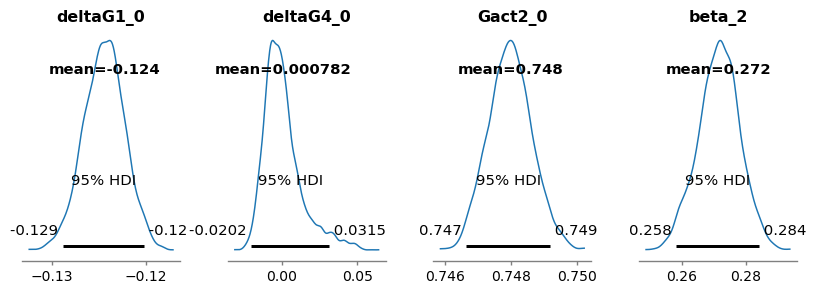

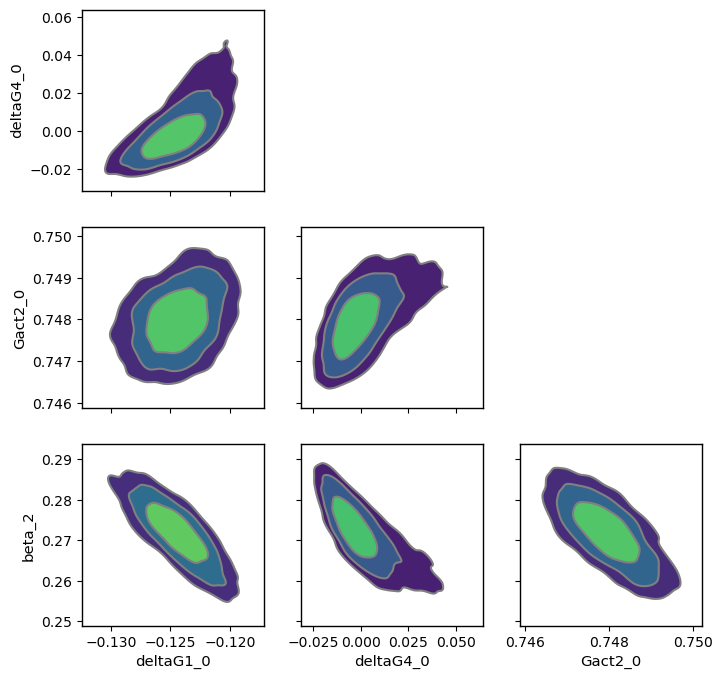

Sampling: [rate]


rate: 0.811


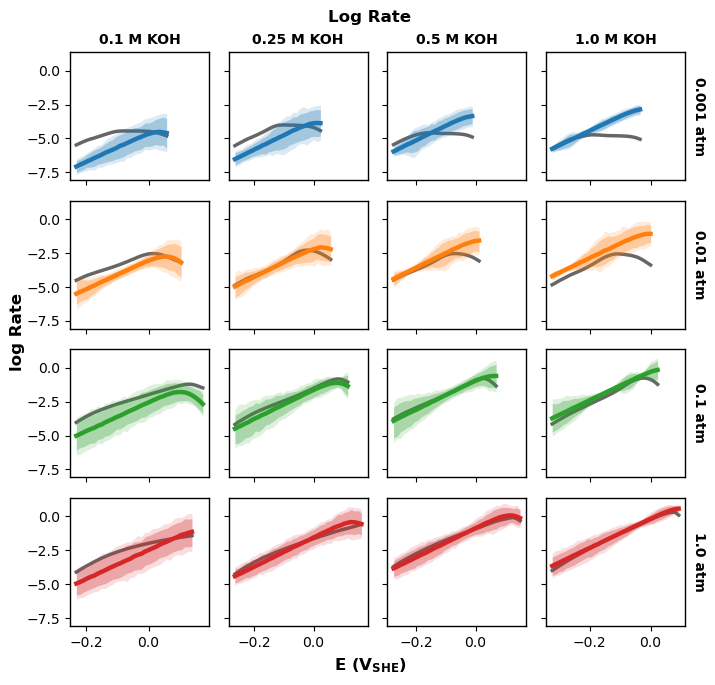

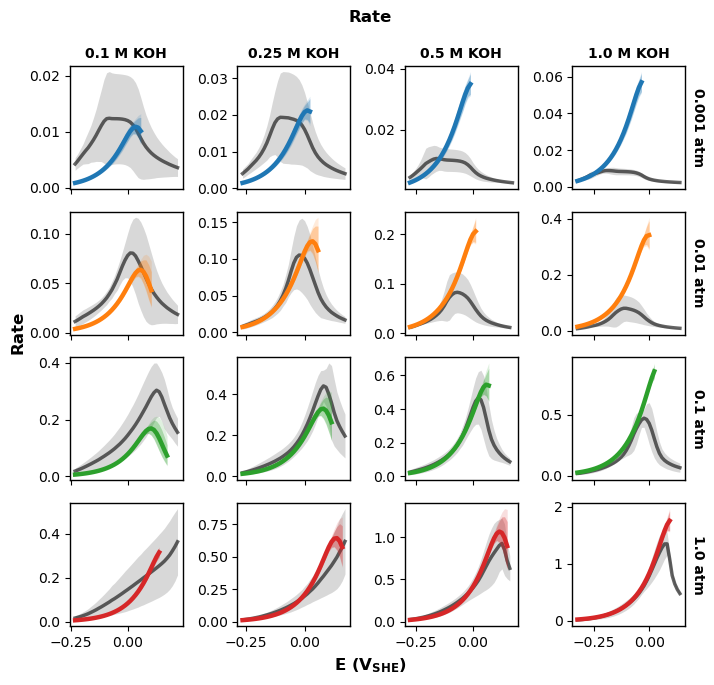

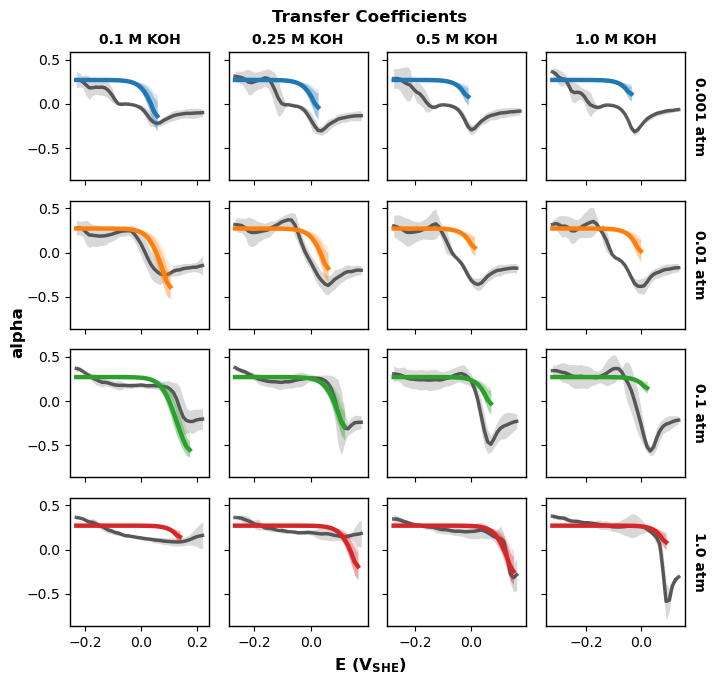

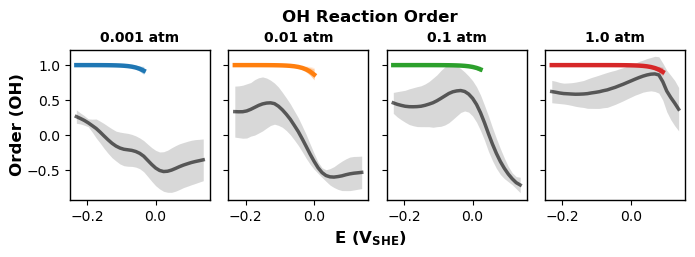

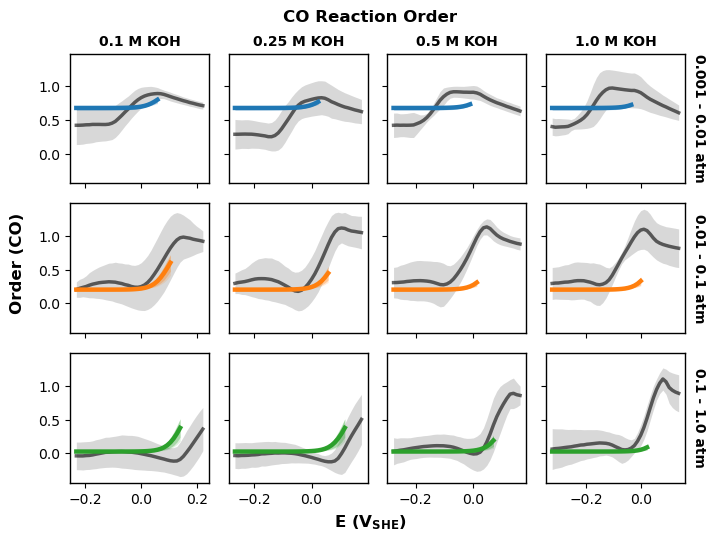

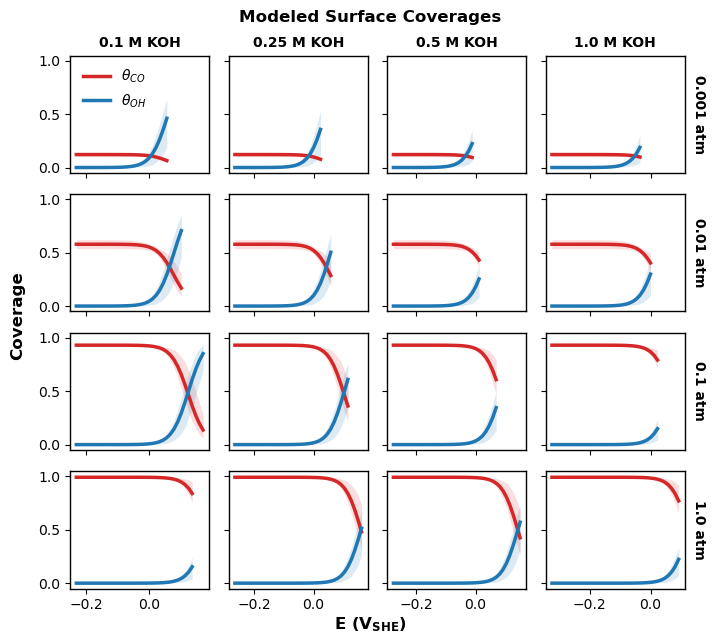

In [9]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# LH 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,239
,3000,0,0.13,31
,3000,0,0.12,23
,3000,0,0.11,31


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -570.92    39.22
p_loo        9.12        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



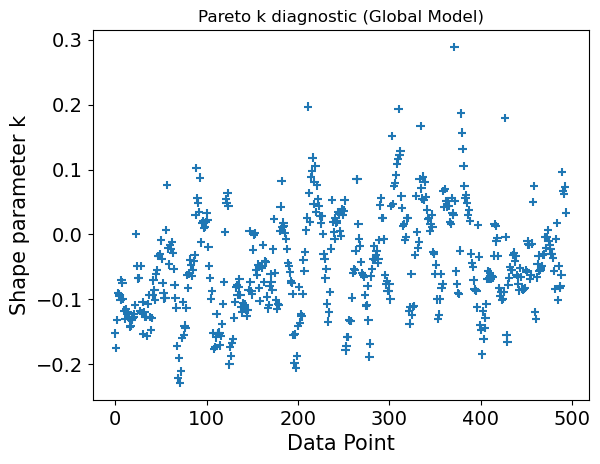

In [10]:
with pm.Model() as LH_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* <-> COOH* + * (QEA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.2) 
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)   
    Gact3_0 = pm.Normal('Gact3_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + term_OH
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_LH_3, loo_LH_3 = fit_and_evaluate(LH_3)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.258  0.057  -0.362   -0.167      0.004    0.003     224.0     255.0   1.01
deltaG4_0 -0.462  0.056  -0.565   -0.371      0.004    0.002     219.0     270.0   1.01
deltaG2_0  0.140  0.057   0.046    0.242      0.004    0.003     225.0     260.0   1.01
Gact3_0    0.750  0.000   0.749    0.751      0.000    0.000    2444.0    2459.0   1.00
beta_3     0.241  0.005   0.232    0.250      0.000    0.000    1765.0    1779.0   1.00


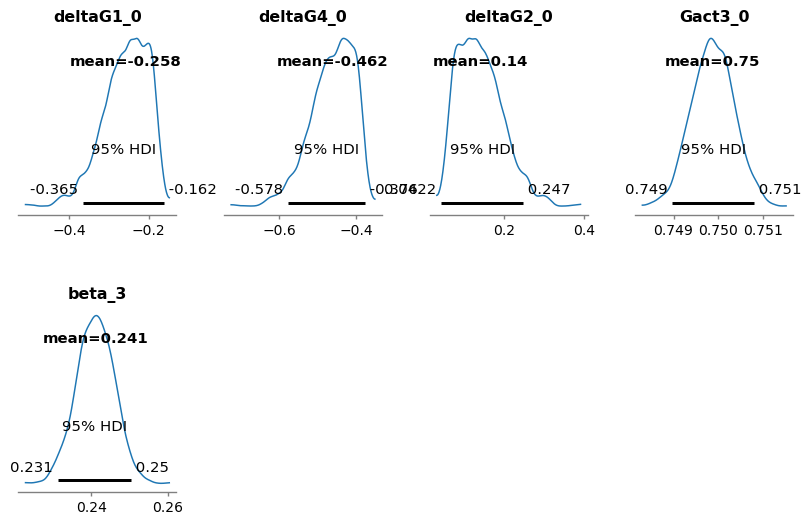

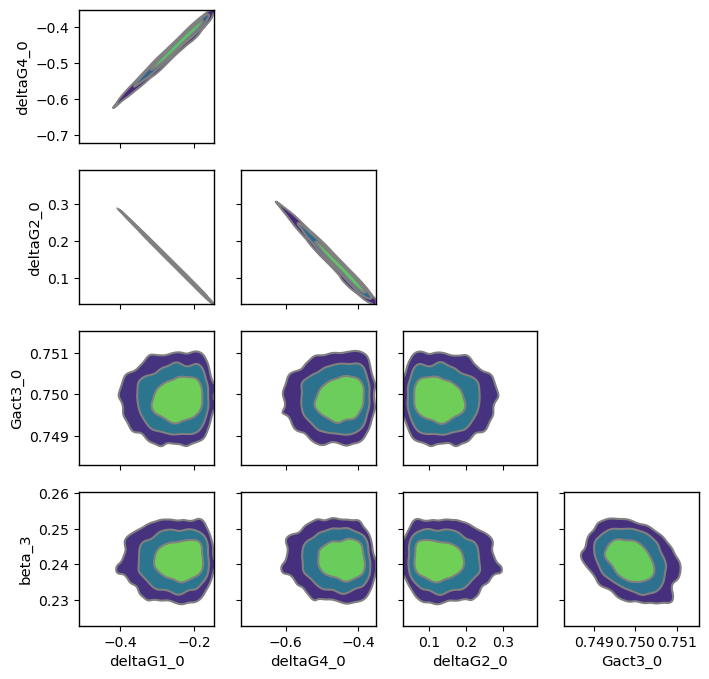

Sampling: [rate]


rate: 0.815


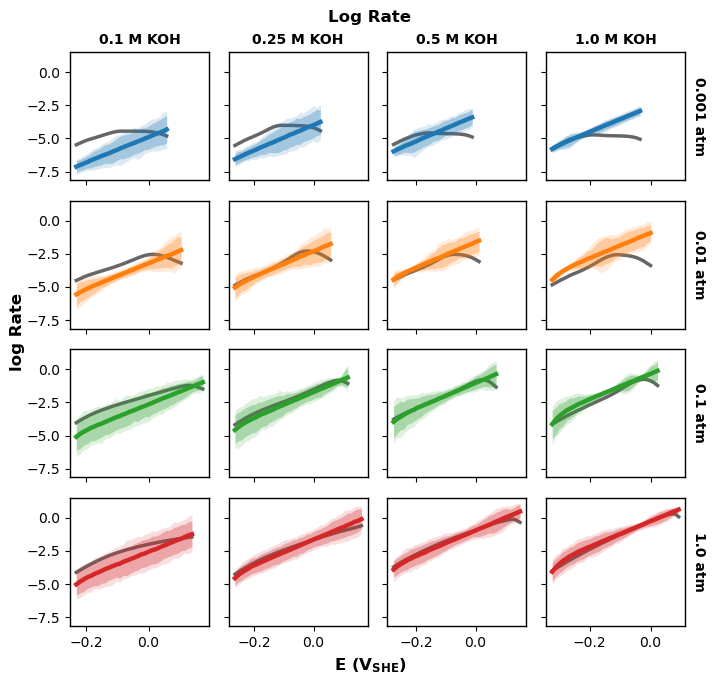

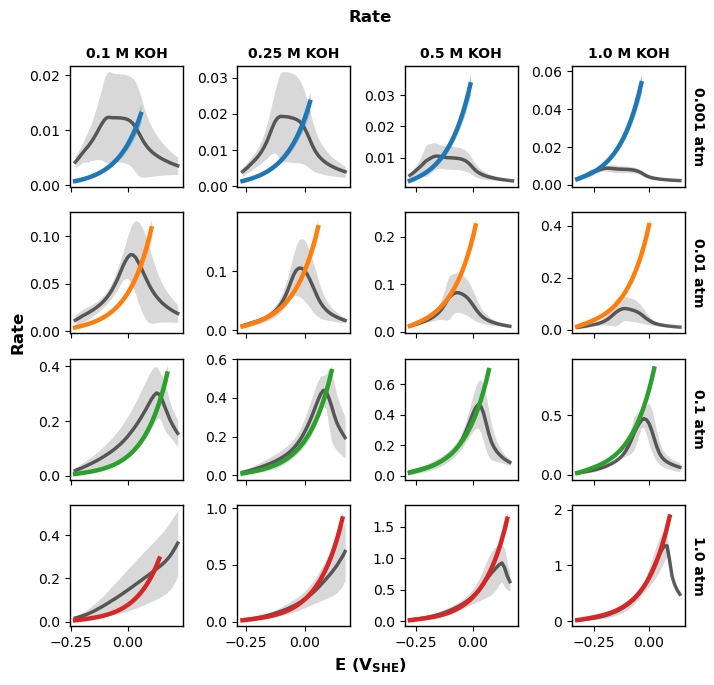

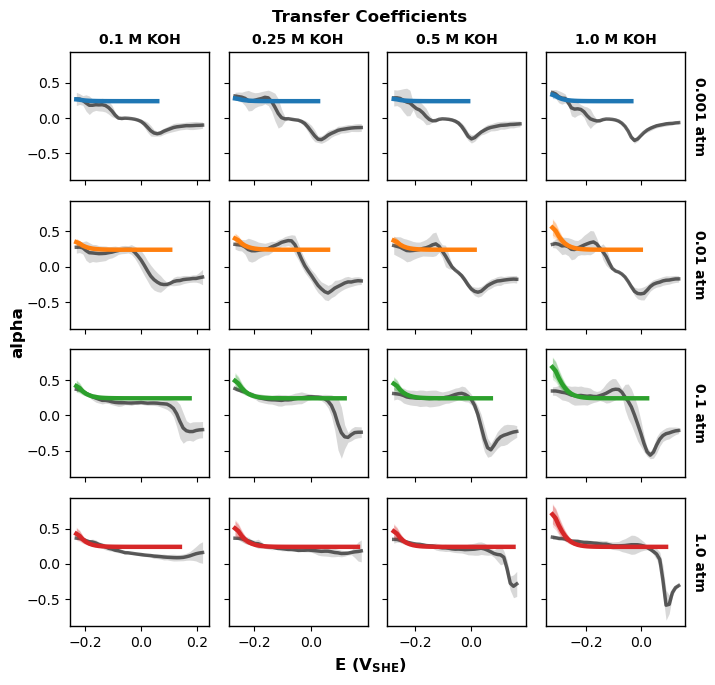

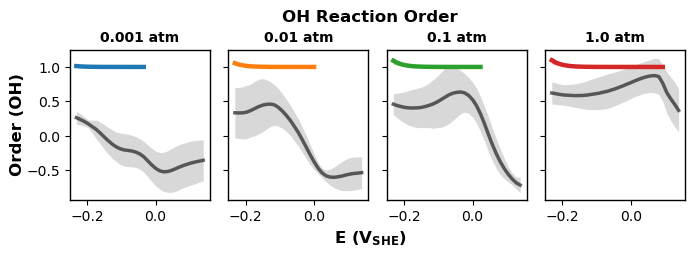

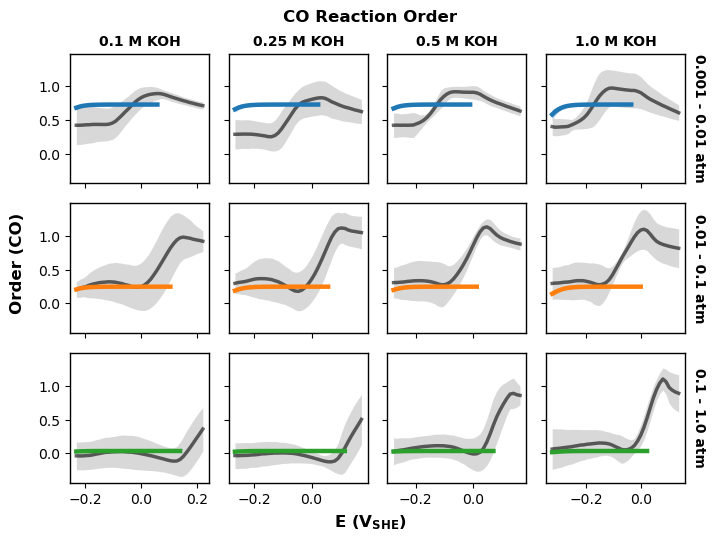

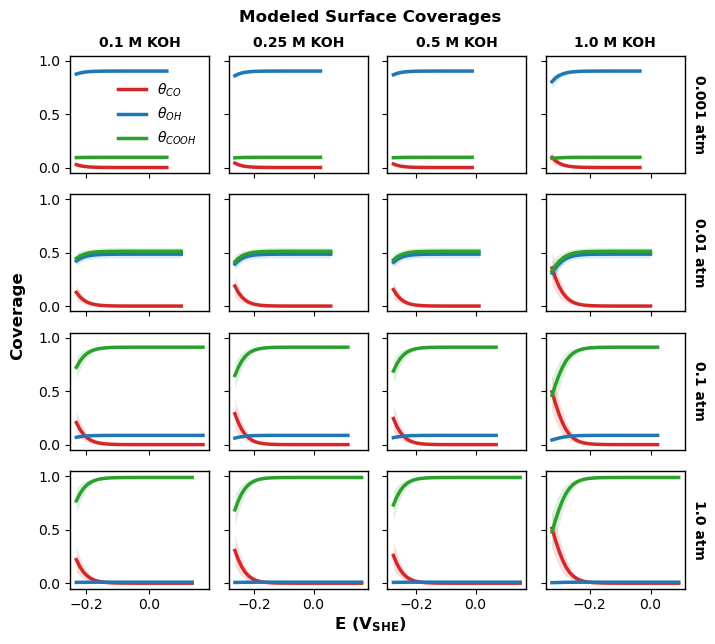

In [11]:
ppc_LH_3 = plot_posteriors(trace_LH_3, LH_3, plot_target)
plot_model_fits(trace_LH_3, ppc_LH_3); plot_coverages(trace_LH_3)

# ER 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.10,307
,3000,0,0.10,31
,3000,0,0.11,31
,3000,0,0.10,63


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -570.71    39.20
p_loo        8.97        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



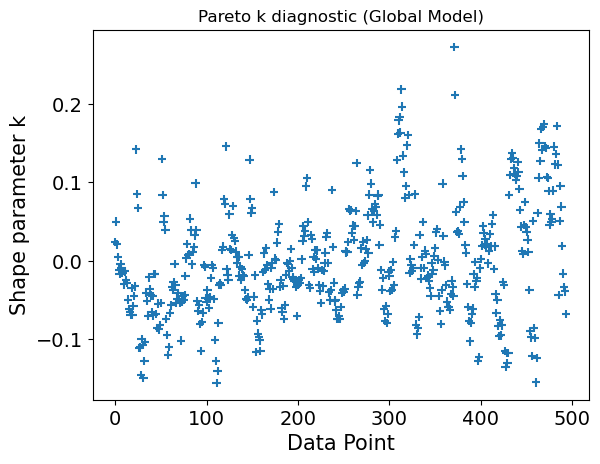

In [12]:
with pm.Model() as ER_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (QEA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact3_0 = pm.Normal('Gact3_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_3, loo_ER_3 = fit_and_evaluate(ER_3)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.275  0.068  -0.400   -0.164      0.003    0.002     450.0     810.0   1.01
deltaG4_0 -0.478  0.067  -0.599   -0.369      0.003    0.002     441.0     825.0   1.01
deltaG2_0 -0.321  0.009  -0.337   -0.306      0.000    0.000    1660.0    1428.0   1.00
Gact3_0    0.750  0.000   0.749    0.751      0.000    0.000    3674.0    2767.0   1.00
beta_3     0.241  0.005   0.232    0.250      0.000    0.000    2442.0    2156.0   1.00


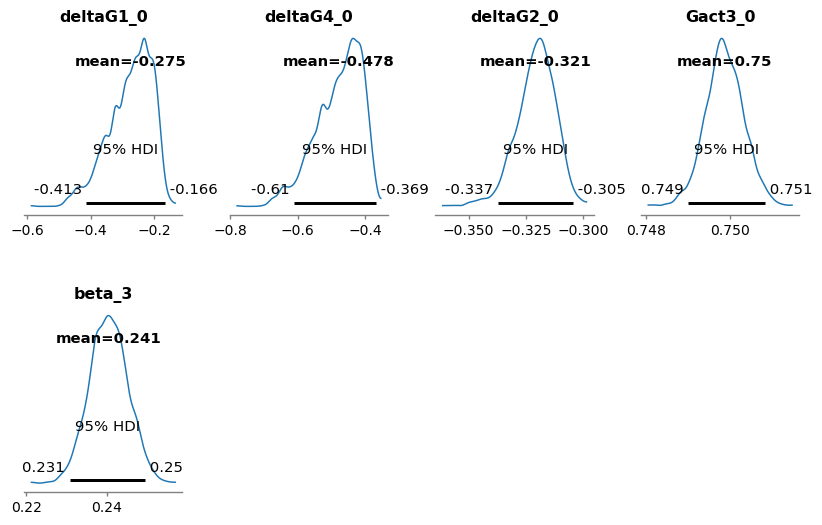

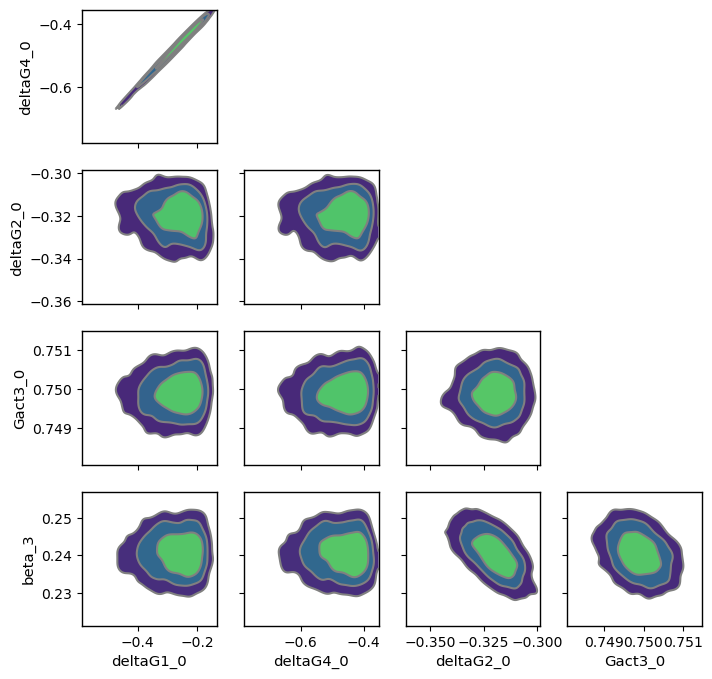

Sampling: [rate]


rate: 0.815


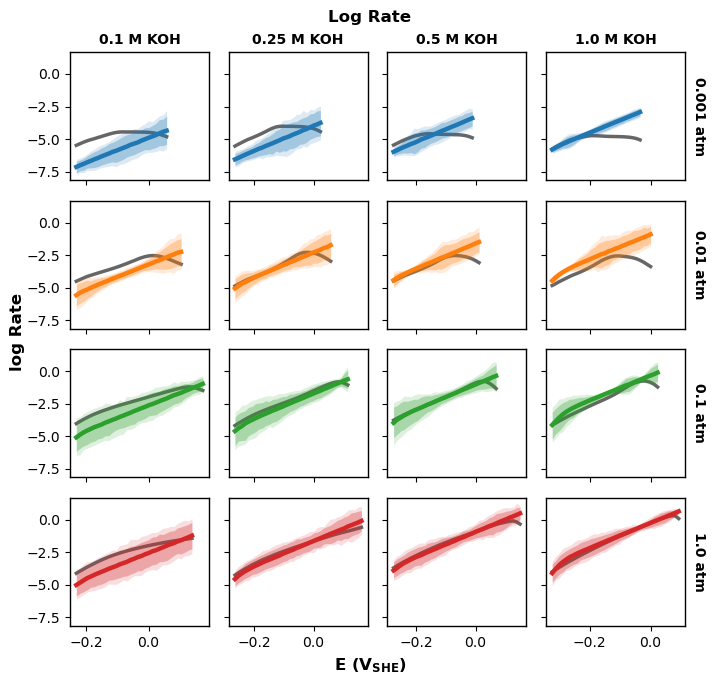

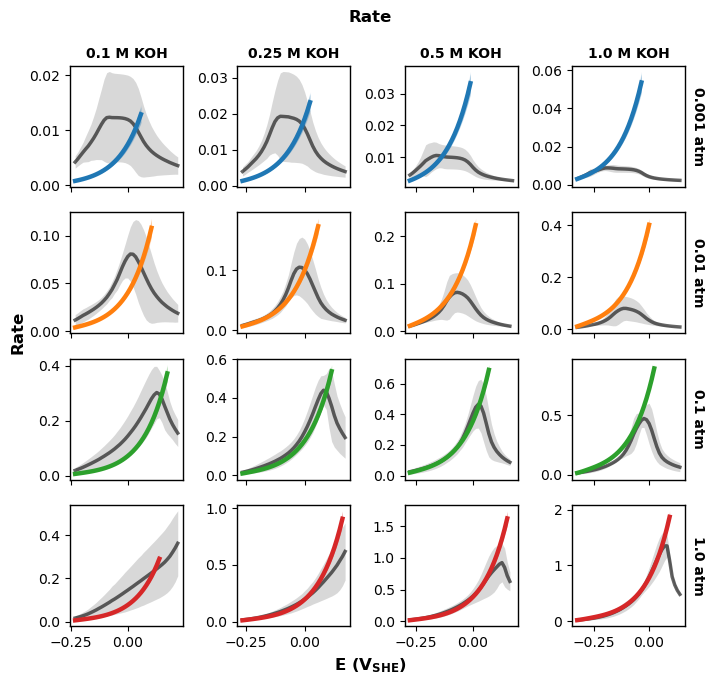

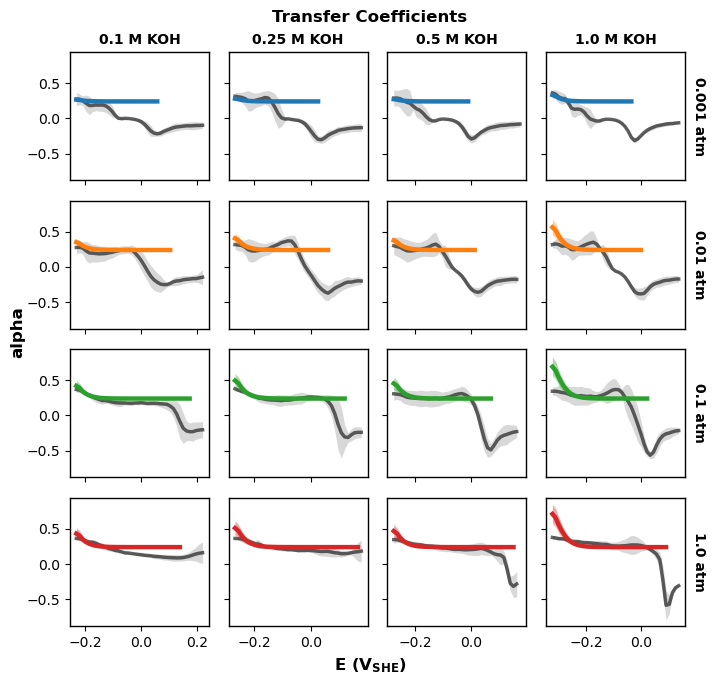

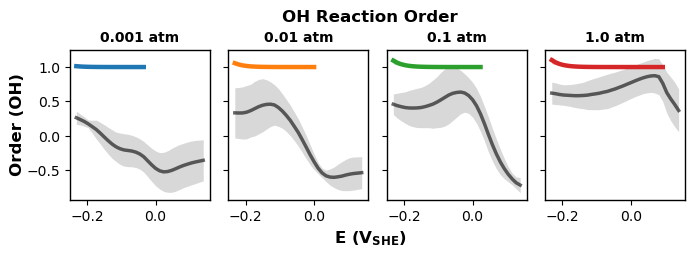

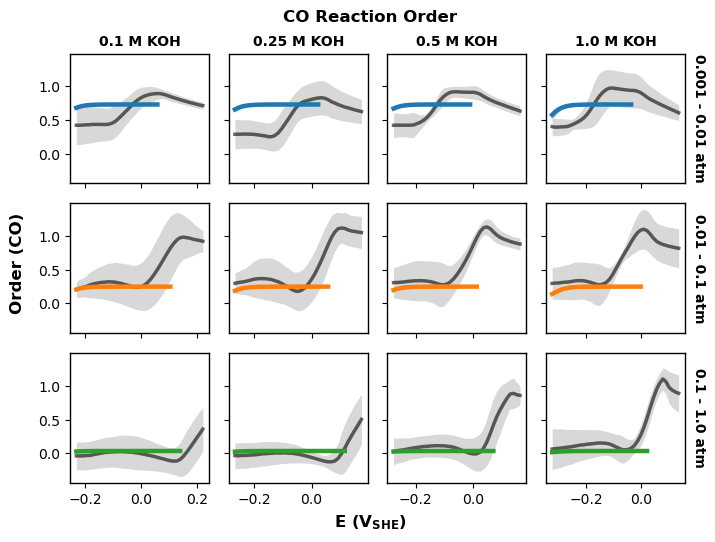

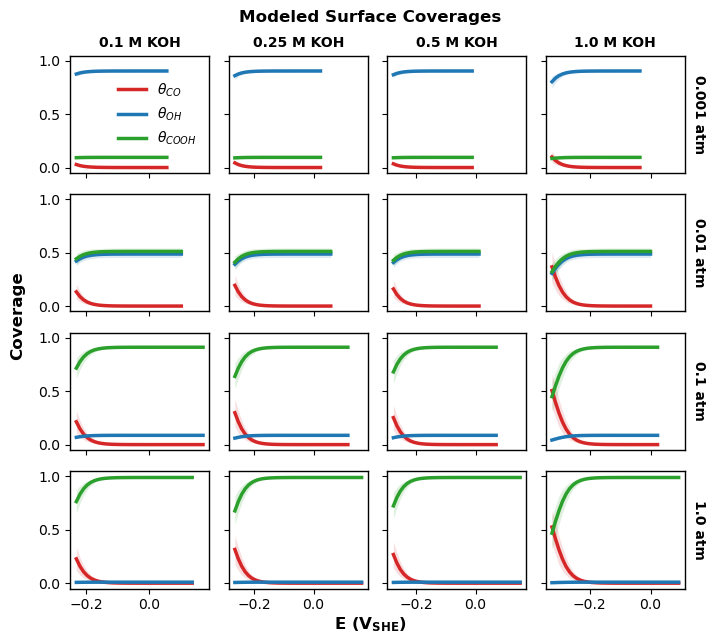

In [13]:
ppc_ER_3 = plot_posteriors(trace_ER_3, ER_3, plot_target)
plot_model_fits(trace_ER_3, ppc_ER_3); plot_coverages(trace_ER_3)

# LH 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.52,7
,3000,0,0.49,7
,3000,0,0.48,7
,3000,0,0.51,7


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -969.69    54.09
p_loo        6.38        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



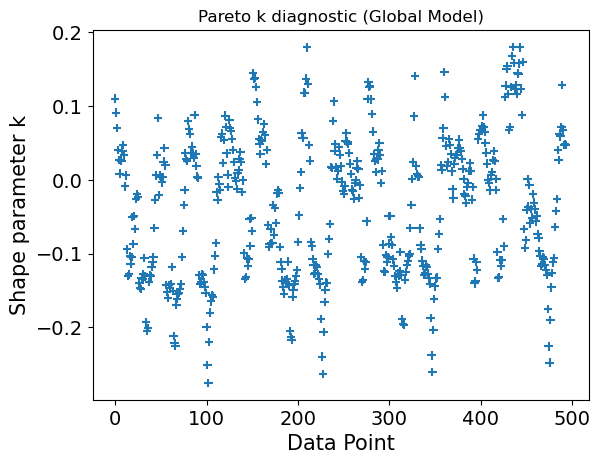

In [14]:
with pm.Model() as LH_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (Fast)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * -> OH* + (e-) (RDS)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)   
    Gact4_0 = pm.Normal('Gact4_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    Gact4 = Gact4_0 - beta_4*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k4 = np.log(kb_J*T/h) - Gact4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO]), axis=0)
    log_theta_CO = term_CO + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))

    # Rate expression
    log_rate_model = log_k4 + log_theta + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_LH_4, loo_LH_4 = fit_and_evaluate(LH_4)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  0.208  0.058   0.122    0.321      0.002    0.002    1659.0    1351.0    1.0
Gact4_0    0.753  0.001   0.752    0.754      0.000    0.000    2502.0    2777.0    1.0
beta_4     0.291  0.004   0.283    0.300      0.000    0.000    2028.0    2197.0    1.0


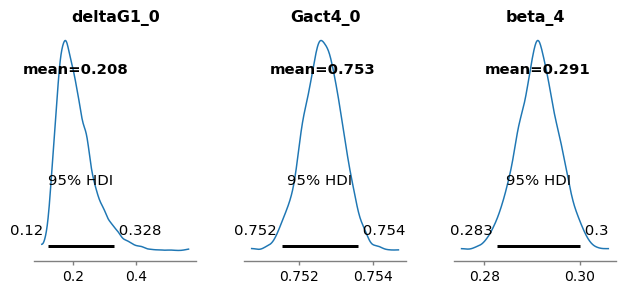

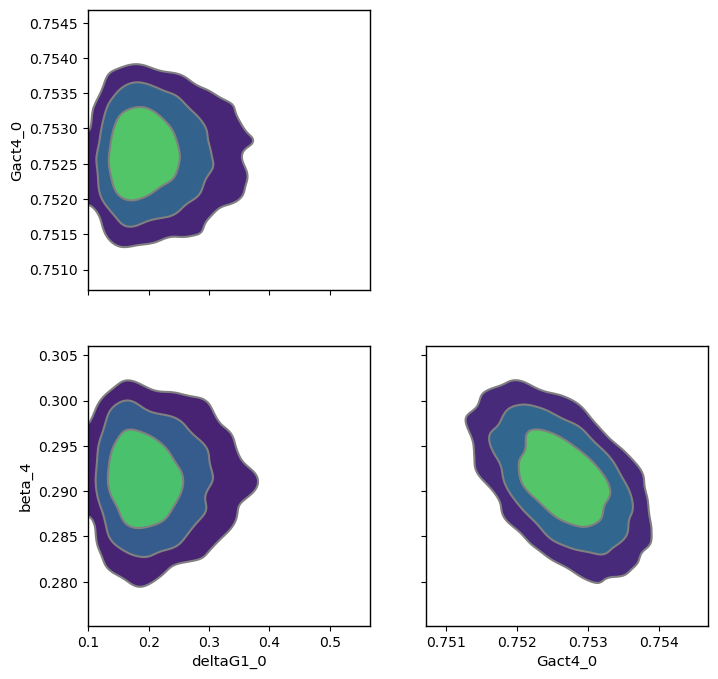

Sampling: [rate]


rate: 0.602


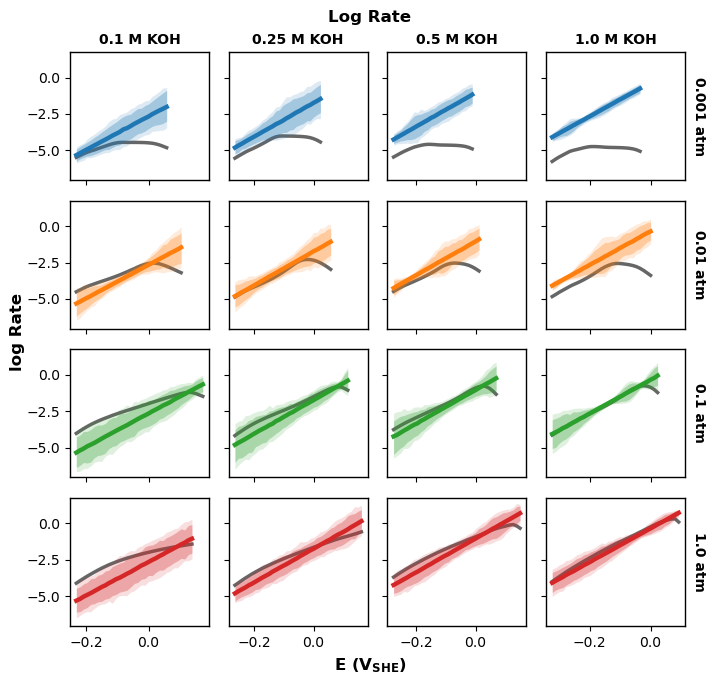

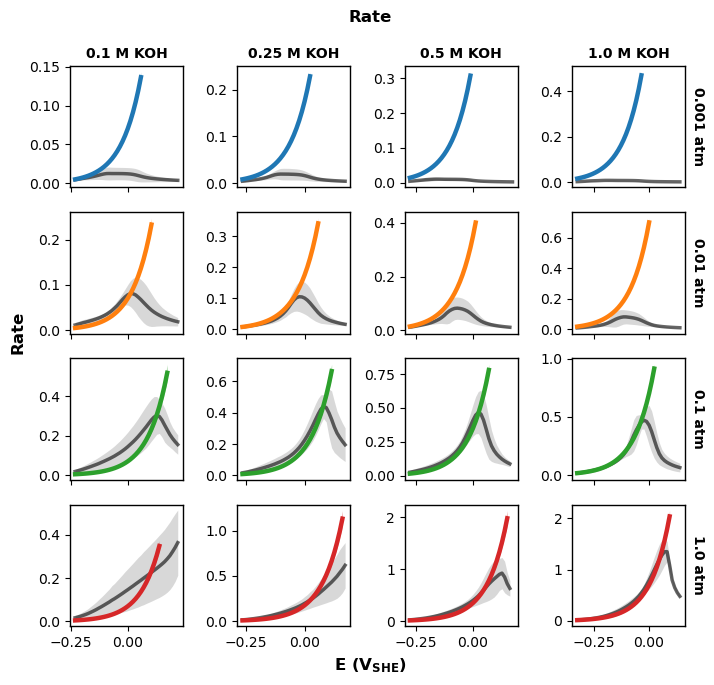

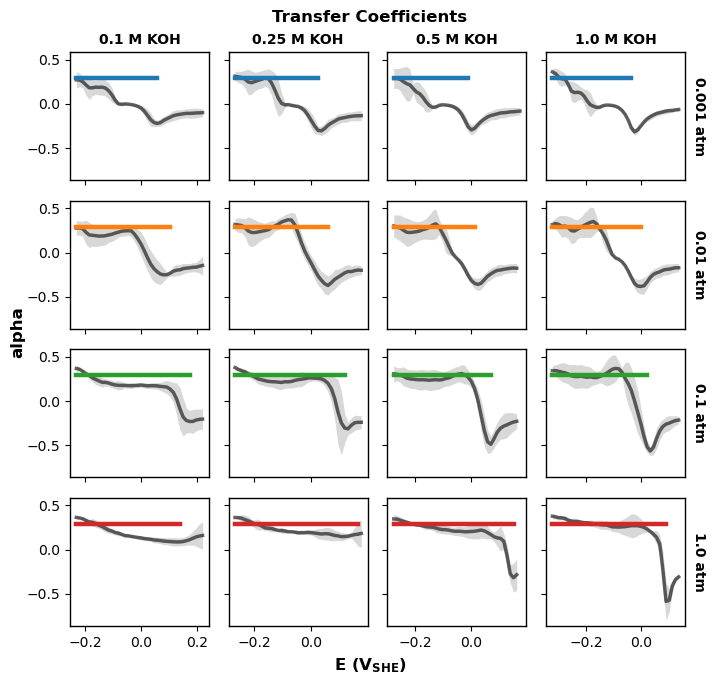

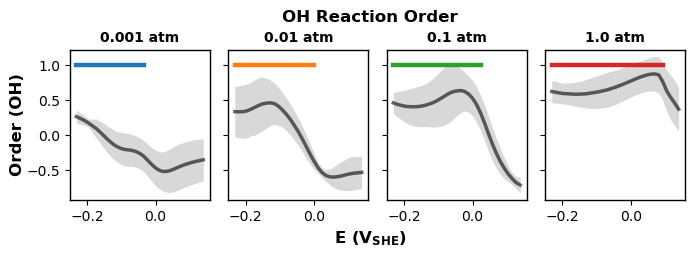

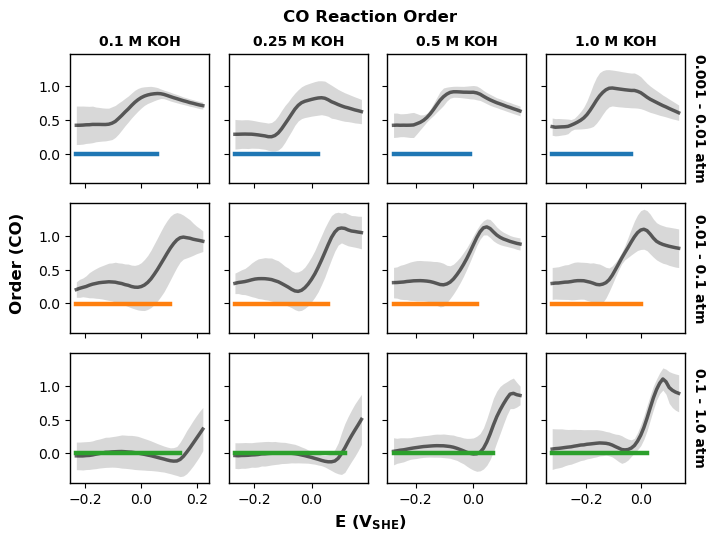

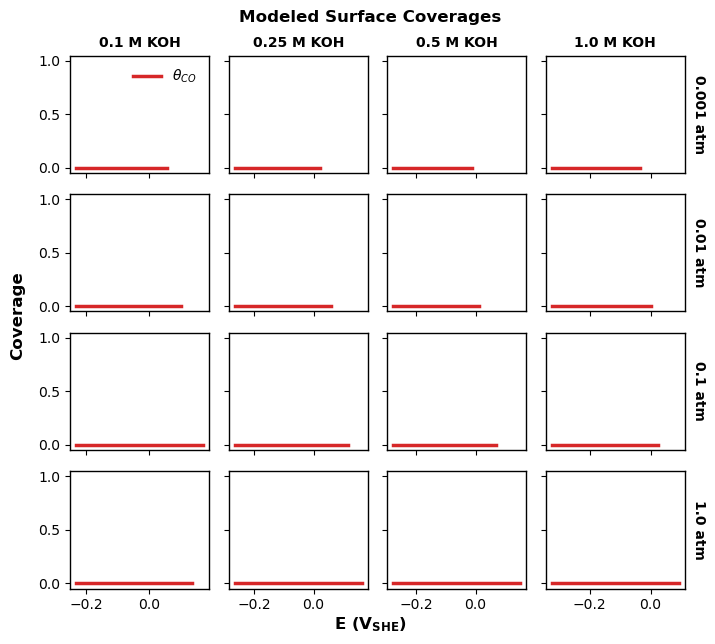

In [15]:
ppc_LH_4 = plot_posteriors(trace_LH_4, LH_4, plot_target)
plot_model_fits(trace_LH_4, ppc_LH_4); plot_coverages(trace_LH_4)

# Comparison

      rank     elpd_loo      p_loo    elpd_diff        weight         se        dse  warning scale
ER_2     0  -567.916797  20.778246     0.000000  5.833766e-01  39.056672   0.000000    False   log
ER_3     1  -570.707481   8.972540     2.790684  3.665937e-01  39.204842  12.493700    False   log
LH_3     2  -570.924339   9.118105     3.007542  2.996172e-15  39.215098  12.415466    False   log
LH_2     3 -2101.105712  75.409069  1533.188915  5.002968e-02  59.527049  70.616919    False   log


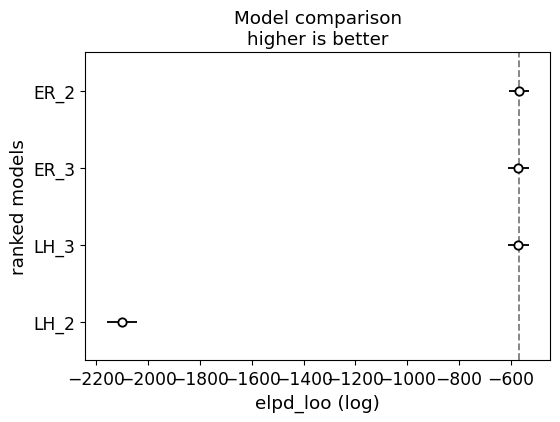

In [16]:
comparison_dict = {
    # "LH_1": loo_LH_1,
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2,
    "LH_3": loo_LH_3,
    "ER_3": loo_ER_3,
    # "LH_4": loo_LH_4,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

In [17]:
# Collision theory comparison
m_CO = 28.01e-3 / 6.022e23 # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # 1 atm to Pa
A_site = F * 1e-4 / (210e-6 * 6.022e23) # Surface area of a single Pt site
sticking_probability = 0.8
k1f = sticking_probability * P_atm_to_Pa*A_site /np.sqrt(2*np.pi*m_CO*kb_J*T)

print(f'CO adsorption rate constant (Collision theory): {k1f:.3e} s^-1') # Too high - just use QEA instead 

CO adsorption rate constant (Collision theory): 1.798e+08 s^-1
